# 🍕 CalorieSnap — EfficientNetV2B0 (Food-101 전체)

| 항목 | 내용 |
|------|------|
| 모델 | EfficientNetV2B0 (keras.applications) |
| 클래스 | Food-101 전체 **101종** |
| 입력 | 224×224×3 / 127.5 - 1.0 → [-1, 1] |
| 증강 | CenterCrop + Rotation + CutOut + ColorJitter |
| 학습 | 2-Stage (헤드 → 전체 파인튜닝 + Cosine LR) |
| 변환 | TFLite Float16 |

⚠️ **런타임 → 런타임 유형 변경 → T4 GPU 선택**


## 1️⃣ 환경 설치

In [1]:
!pip install -q tensorflow-datasets>=4.9 matplotlib seaborn scikit-learn
print('✅ 설치 완료')

✅ 설치 완료


In [2]:
import os, json, shutil, time
import numpy as np
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Google Drive 마운트

In [3]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/CalorieSnap_final'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'저장 경로: {SAVE_DIR}')

Mounted at /content/drive
저장 경로: /content/drive/MyDrive/CalorieSnap_final


## 3️⃣ 설정

In [4]:
# Food-101 전체 101종 학습
NUM_CLASSES   = 101
IMG_SIZE      = 224
BATCH_SIZE    = 32
SEED          = 42

# ── 학습 설정 ──────────────────────────────────────────────────
STAGE1_EPOCHS = 5      # 헤드만 학습 (backbone 동결)
STAGE2_EPOCHS = 30     # 전체 파인튜닝 (클래스 수 증가 → 에폭 추가)
STAGE1_LR     = 1e-3
STAGE2_LR     = 5e-5   # 전체 파인튜닝 시 낮은 LR

print(f'클래스 수: {NUM_CLASSES} (Food-101 전체)')


클래스 수: 101 (Food-101 전체)


## 4️⃣ Food-101 로드 & 필터링

In [5]:
print('Food-101 로드 중 (최초 실행 시 ~20분)...')
(ds_train_full, ds_val_full, ds_test_full), info = tfds.load(
    'food101',
    split=['train[:80%]', 'train[80%:]', 'validation'],
    with_info=True,
    as_supervised=True,
)

# Food-101의 클래스명 목록 (tfds 기준 알파벳 정렬, 인덱스 0~100)
all_class_names = info.features['label'].names

assert len(all_class_names) == 101, f'예상 101개, 실제 {len(all_class_names)}개'
assert NUM_CLASSES == len(all_class_names), 'NUM_CLASSES 불일치!'

print(f'\nFood-101 전체 클래스: {len(all_class_names)}')
for idx, cls in enumerate(all_class_names):
    print(f'  {idx:3d}. {cls}')


Food-101 로드 중 (최초 실행 시 ~20분)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.NTG6FU_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.NTG6FU_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.

Food-101 전체 클래스: 101
    0. apple_pie
    1. baby_back_ribs
    2. baklava
    3. beef_carpaccio
    4. beef_tartare
    5. beet_salad
    6. beignets
    7. bibimbap
    8. bread_pudding
    9. breakfast_burrito
   10. bruschetta
   11. caesar_salad
   12. cannoli
   13. caprese_salad
   14. carrot_cake
   15. ceviche
   16. cheesecake
   17. cheese_plate
   18. chicken_curry
   19. chicken_quesadilla
   20. chicken_wings
   21. chocolate_cake
   22. chocolate_mousse
   23. churros
   24. clam_chowder
   25. club_sandwich
   26. crab_cakes
   27. creme_brulee
   28. croque_madame
   29. cup_cakes
   30. deviled_eggs
   31. donuts
   32. dumplings
   33. edamame
   34. eggs_benedict
   35. escargots
   36. falafel
   37. filet_mignon
   38. fish_and_chips
   39. foie_gras
   40. french_fries
   41. french_onion_soup
   42. french_toast
   43. fried_calamari
   44.

In [6]:
# 전체 101종 학습 — 필터링 없이 원본 데이터셋 그대로 사용
# Food-101의 레이블은 이미 0~100 정수이므로 리맵 불필요
ds_train_filtered = ds_train_full
ds_val_filtered   = ds_val_full
ds_test_filtered  = ds_test_full

print('샘플 수 카운트 중...')
n_train = sum(1 for _ in ds_train_filtered)
n_val   = sum(1 for _ in ds_val_filtered)
n_test  = sum(1 for _ in ds_test_filtered)
print(f'Train: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}')


샘플 수 카운트 중...
Train: 60,600  |  Val: 15,150  |  Test: 25,250


## 5️⃣ 전처리 & 데이터 증강

**개선된 증강 목록**
- CenterCrop — 비율 유지 (Flutter와 동일)
- RandomRotation — 90° 단위 회전 (다양한 촬영 각도 대응)
- RandomFlip — 좌우 반전
- ColorJitter — 밝기 / 대비 / 채도
- **CutOut** — 랜덤 영역 마스킹 (유사 클래스 과적합 방지)
- 정규화 — `/ 127.5 - 1.0` → **[-1, 1]**

steps_per_epoch  : 1893
validation_steps : 473


/tmp/ipykernel_671/2411740243.py:114: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2411740243.py:114: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2411740243.py:114: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2411740243.py:114: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2411740243.py:115: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_augmented.png', dpi=100)
/tmp/ipykernel_671/2411740243.py:115: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_augmented.png', dpi=100)
/tmp/ipykernel_671/2411740243.py:115: UserWarning: Glyph 4

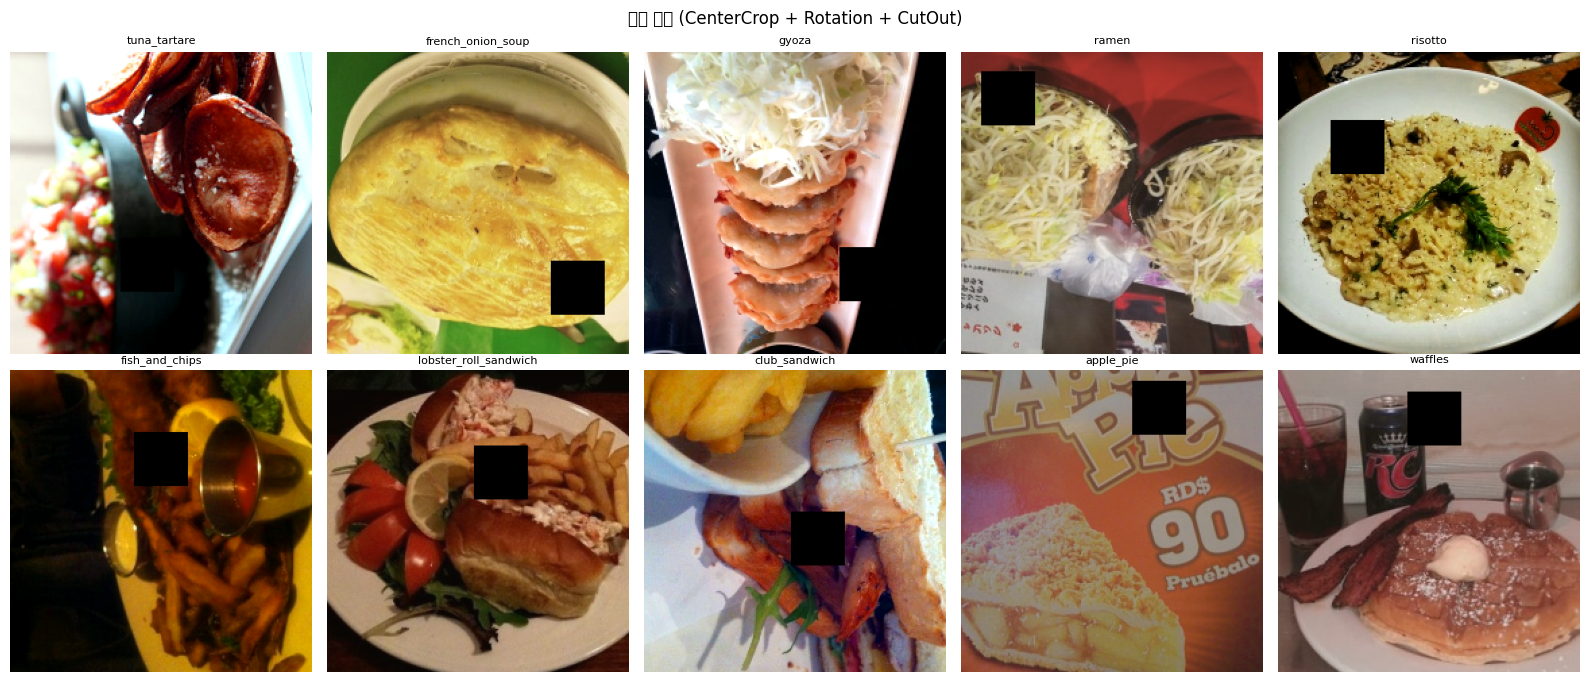

✅ 전처리 확인 완료


In [7]:
AUTOTUNE = tf.data.AUTOTUNE


# ── CenterCrop ─────────────────────────────────────────────────
def center_crop(image):
    """Flutter copyCrop() 과 동일 로직 — 비율 유지 정사각형 자르기"""
    h         = tf.shape(image)[0]
    w         = tf.shape(image)[1]
    crop_size = tf.minimum(h, w)
    offset_h  = (h - crop_size) // 2
    offset_w  = (w - crop_size) // 2
    return tf.image.crop_to_bounding_box(image, offset_h, offset_w, crop_size, crop_size)


# ── CutOut ─────────────────────────────────────────────────────
def random_cutout(image, mask_size=40):
    """
    랜덤 영역(mask_size × mask_size)을 0으로 마스킹
    유사 클래스(스파게티 볼/카르, 라면/미소국 등) 과적합 방지
    """
    h  = IMG_SIZE
    w  = IMG_SIZE
    half = mask_size // 2

    cy = tf.random.uniform([], half, h - half, dtype=tf.int32)
    cx = tf.random.uniform([], half, w - half, dtype=tf.int32)

    y1 = cy - half
    y2 = cy + half
    x1 = cx - half
    x2 = cx + half

    # 행/열 마스크 생성 (graph-mode 호환)
    row_mask = tf.logical_and(tf.range(h) >= y1, tf.range(h) < y2)
    col_mask = tf.logical_and(tf.range(w) >= x1, tf.range(w) < x2)

    row_mask = tf.reshape(row_mask, [h, 1, 1])
    col_mask = tf.reshape(col_mask, [1, w, 1])
    patch    = tf.logical_and(row_mask, col_mask)
    patch    = tf.broadcast_to(patch, [h, w, 3])

    return tf.where(patch, tf.zeros_like(image), image)


# ── 학습 전처리 ────────────────────────────────────────────────
def preprocess_train(image, label):
    # 1. CenterCrop (비율 유지)
    image = center_crop(image)

    # 2. 리사이즈 (약간 크게 → RandomCrop)
    image = tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20])
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])

    # 3. RandomRotation — 90° 단위
    #    음식 사진은 세로/가로 촬영이 혼재 → 회전 불변성 학습
    k     = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)

    # 4. 좌우 반전
    image = tf.image.random_flip_left_right(image)

    # 5. ColorJitter
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0, 255)

    # 6. CutOut (40×40 랜덤 마스킹)
    image = random_cutout(image, mask_size=40)

    # 7. [-1, 1] 정규화 (EfficientNetV2B0 기준)
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


# ── 평가 전처리 ─────────────────────────────────────────────────
def preprocess_eval(image, label):
    # Flutter preprocess_eval() 과 동일
    image = center_crop(image)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 127.5 - 1.0
    return image, label


def build_dataset(ds, fn, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    ds = ds.map(fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if repeat:
        ds = ds.repeat()
    return ds.prefetch(AUTOTUNE)


train_ds = build_dataset(ds_train_filtered, preprocess_train, shuffle=True, repeat=True)
val_ds   = build_dataset(ds_val_filtered,   preprocess_eval)
test_ds  = build_dataset(ds_test_filtered,  preprocess_eval)

steps_per_epoch  = n_train // BATCH_SIZE
validation_steps = n_val   // BATCH_SIZE
print(f'steps_per_epoch  : {steps_per_epoch}')
print(f'validation_steps : {validation_steps}')

# 증강 결과 시각화 (역정규화)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        img_show = np.clip((images[i].numpy() + 1.0) / 2.0, 0, 1)
        ax.imshow(img_show)
        ax.set_title(all_class_names[labels[i].numpy()], fontsize=8)
        ax.axis('off')
plt.suptitle('증강 샘플 (CenterCrop + Rotation + CutOut)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/sample_augmented.png', dpi=100)
plt.show()
print('✅ 전처리 확인 완료')

## 6️⃣ 모델 구성 (EfficientNetV2B0)

In [8]:
def build_model(num_classes, freeze_backbone=True):
    # ─────────────────────────────────────────────────────────
    #  EfficientNetV2B0
    #  - Fused-MBConv: MobileNetV3 Hard-Swish 문제 없음
    #  - Float16 TFLite 정확도 안정적
    #  - MobileNetV3Small 대비 정확도 +5~8%p 예상
    # ─────────────────────────────────────────────────────────
    base_model = keras.applications.EfficientNetV2B0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=False,  # 섹션5에서 직접 [-1,1] 정규화
    )
    base_model.trainable = not freeze_backbone

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x       = base_model(inputs, training=not freeze_backbone)
    x       = keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x       = keras.layers.BatchNormalization(name='bn')(x)
    x       = keras.layers.Dropout(0.3, name='dropout')(x)
    outputs = keras.layers.Dense(
        num_classes, activation='softmax', name='predictions'
    )(x)

    return keras.Model(inputs, outputs, name='efficientnetv2b0_food'), base_model


model, base_model = build_model(NUM_CLASSES, freeze_backbone=True)
model.summary()

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f'\n학습 가능: {trainable:,}  |  동결: {frozen:,}')

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "efficientnetv2b0_food"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,053,813 (23.09 MB)

 Trainable params: 131,941 (515.39 KB)

 Non-trainable params: 5,921,872 (22.59 MB)


학습 가능: 131,941  |  동결: 5,921,872


## 7️⃣ Stage 1 — 헤드 학습 (backbone 동결)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Stage 1: 헤드 학습 ===')
t0 = time.time()
history1 = model.fit(
    train_ds,
    epochs=STAGE1_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

=== Stage 1: 헤드 학습 ===
Epoch 1/5
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 413s 197ms/step - accuracy: 0.3782 - loss: 2.6623 - val_accuracy: 0.5784 - val_loss: 1.6609
Epoch 2/5
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 386s 193ms/step - accuracy: 0.4698 - loss: 2.1733 - val_accuracy: 0.6016 - val_loss: 1.5647
Epoch 3/5
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 366s 193ms/step - accuracy: 0.4904 - loss: 2.0631 - val_accuracy: 0.6103 - val_loss: 1.5104
Epoch 4/5
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 365s 193ms/step - accuracy: 0.5019 - loss: 2.0029 - val_accuracy: 0.6210 - val_loss: 1.4790
Epoch 5/5
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 366s 194ms/step - accuracy: 0.5103 - loss: 1.9559 - val_accuracy: 0.6221 - val_loss: 1.4635
Restoring model weights from the end of the best epoch: 5.
완료 (1896초)  |  최고 val_accuracy: 0.6221


## 8️⃣ Stage 2 — 전체 파인튜닝

**개선사항**
- 기존: 상위 50% 레이어만 해제
- 변경: **전체 backbone 해제** + **낮은 LR (5e-5)** + **Cosine Decay**

In [10]:
# 전체 backbone 파인튜닝
base_model.trainable = True

trainable_now = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f'전체 학습 파라미터: {trainable_now:,}')

# Cosine Decay LR: 학습 후반부에 LR을 서서히 줄여 수렴 안정화
total_steps = STAGE2_EPOCHS * steps_per_epoch
cosine_lr   = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=STAGE2_LR,
    decay_steps=total_steps,
    alpha=1e-6,           # 최소 LR
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('\n=== Stage 2: 전체 파인튜닝 시작 ===')
t0 = time.time()
history2 = model.fit(
    train_ds,
    epochs=STAGE2_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath='/content/best_model.keras',
            monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
    ],
    verbose=1,
)
print(f'완료 ({time.time()-t0:.0f}초)  |  최고 val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

전체 학습 파라미터: 5,990,645

=== Stage 2: 전체 파인튜닝 시작 ===
Epoch 1/30
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4537 - loss: 2.2307
Epoch 1: val_accuracy improved from None to 0.69477, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 508s 214ms/step - accuracy: 0.5316 - loss: 1.8601 - val_accuracy: 0.6948 - val_loss: 1.1727
Epoch 2/30
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6245 - loss: 1.4533
Epoch 2: val_accuracy improved from 0.69477 to 0.72648, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 451s 211ms/step - accuracy: 0.6407 - loss: 1.3816 - val_accuracy: 0.7265 - val_loss: 1.0478
Epoch 3/30
1893/1893 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6691 - loss: 1.2692
Epoch 3: val_accuracy improved from 0.72648 to 0.74749, saving model to /content/best_model.keras

Epoch 3: finished s

/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/2779077493.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

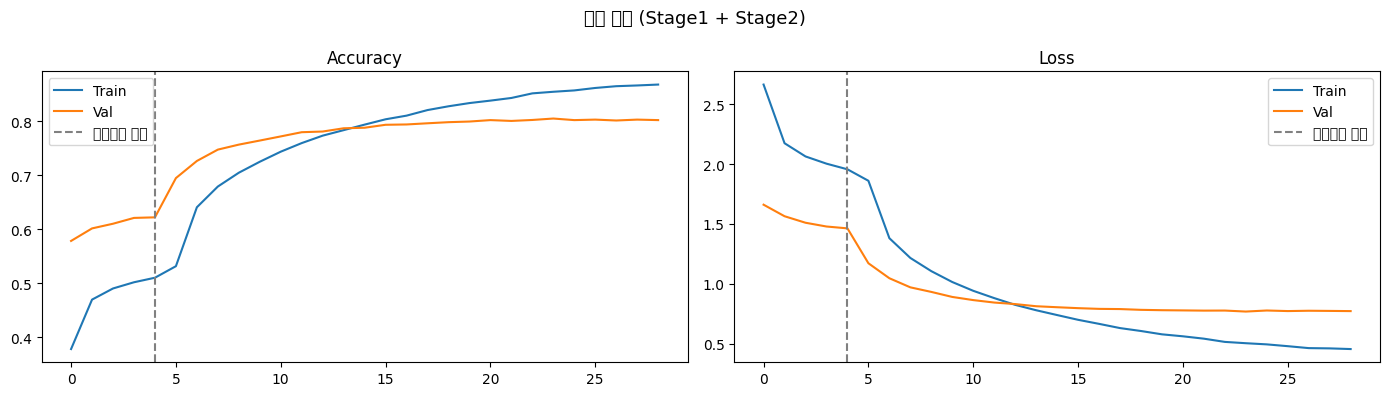

In [11]:
# 학습 곡선
acc   = history1.history['accuracy']     + history2.history['accuracy']
val   = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss  = history1.history['loss']         + history2.history['loss']
vloss = history1.history['val_loss']     + history2.history['val_loss']
split = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, t, v, title in [
    (axes[0], acc,  val,   'Accuracy'),
    (axes[1], loss, vloss, 'Loss'),
]:
    ax.plot(t, label='Train')
    ax.plot(v, label='Val')
    ax.axvline(x=split - 1, color='gray', linestyle='--', label='파인튜닝 시작')
    ax.set_title(title)
    ax.legend()
plt.suptitle('학습 곡선 (Stage1 + Stage2)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

## 9️⃣ 평가 (Test Set)

In [12]:
best_model = keras.models.load_model('/content/best_model.keras')

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\n✅ Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'   Test Loss     : {test_loss:.4f}')

790/790 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.8496 - loss: 0.5351

✅ Test Accuracy : 0.8496  (85.0%)
   Test Loss     : 0.5351


/tmp/ipykernel_671/950976873.py:24: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_671/950976873.py:25: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/confusion_matrix.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


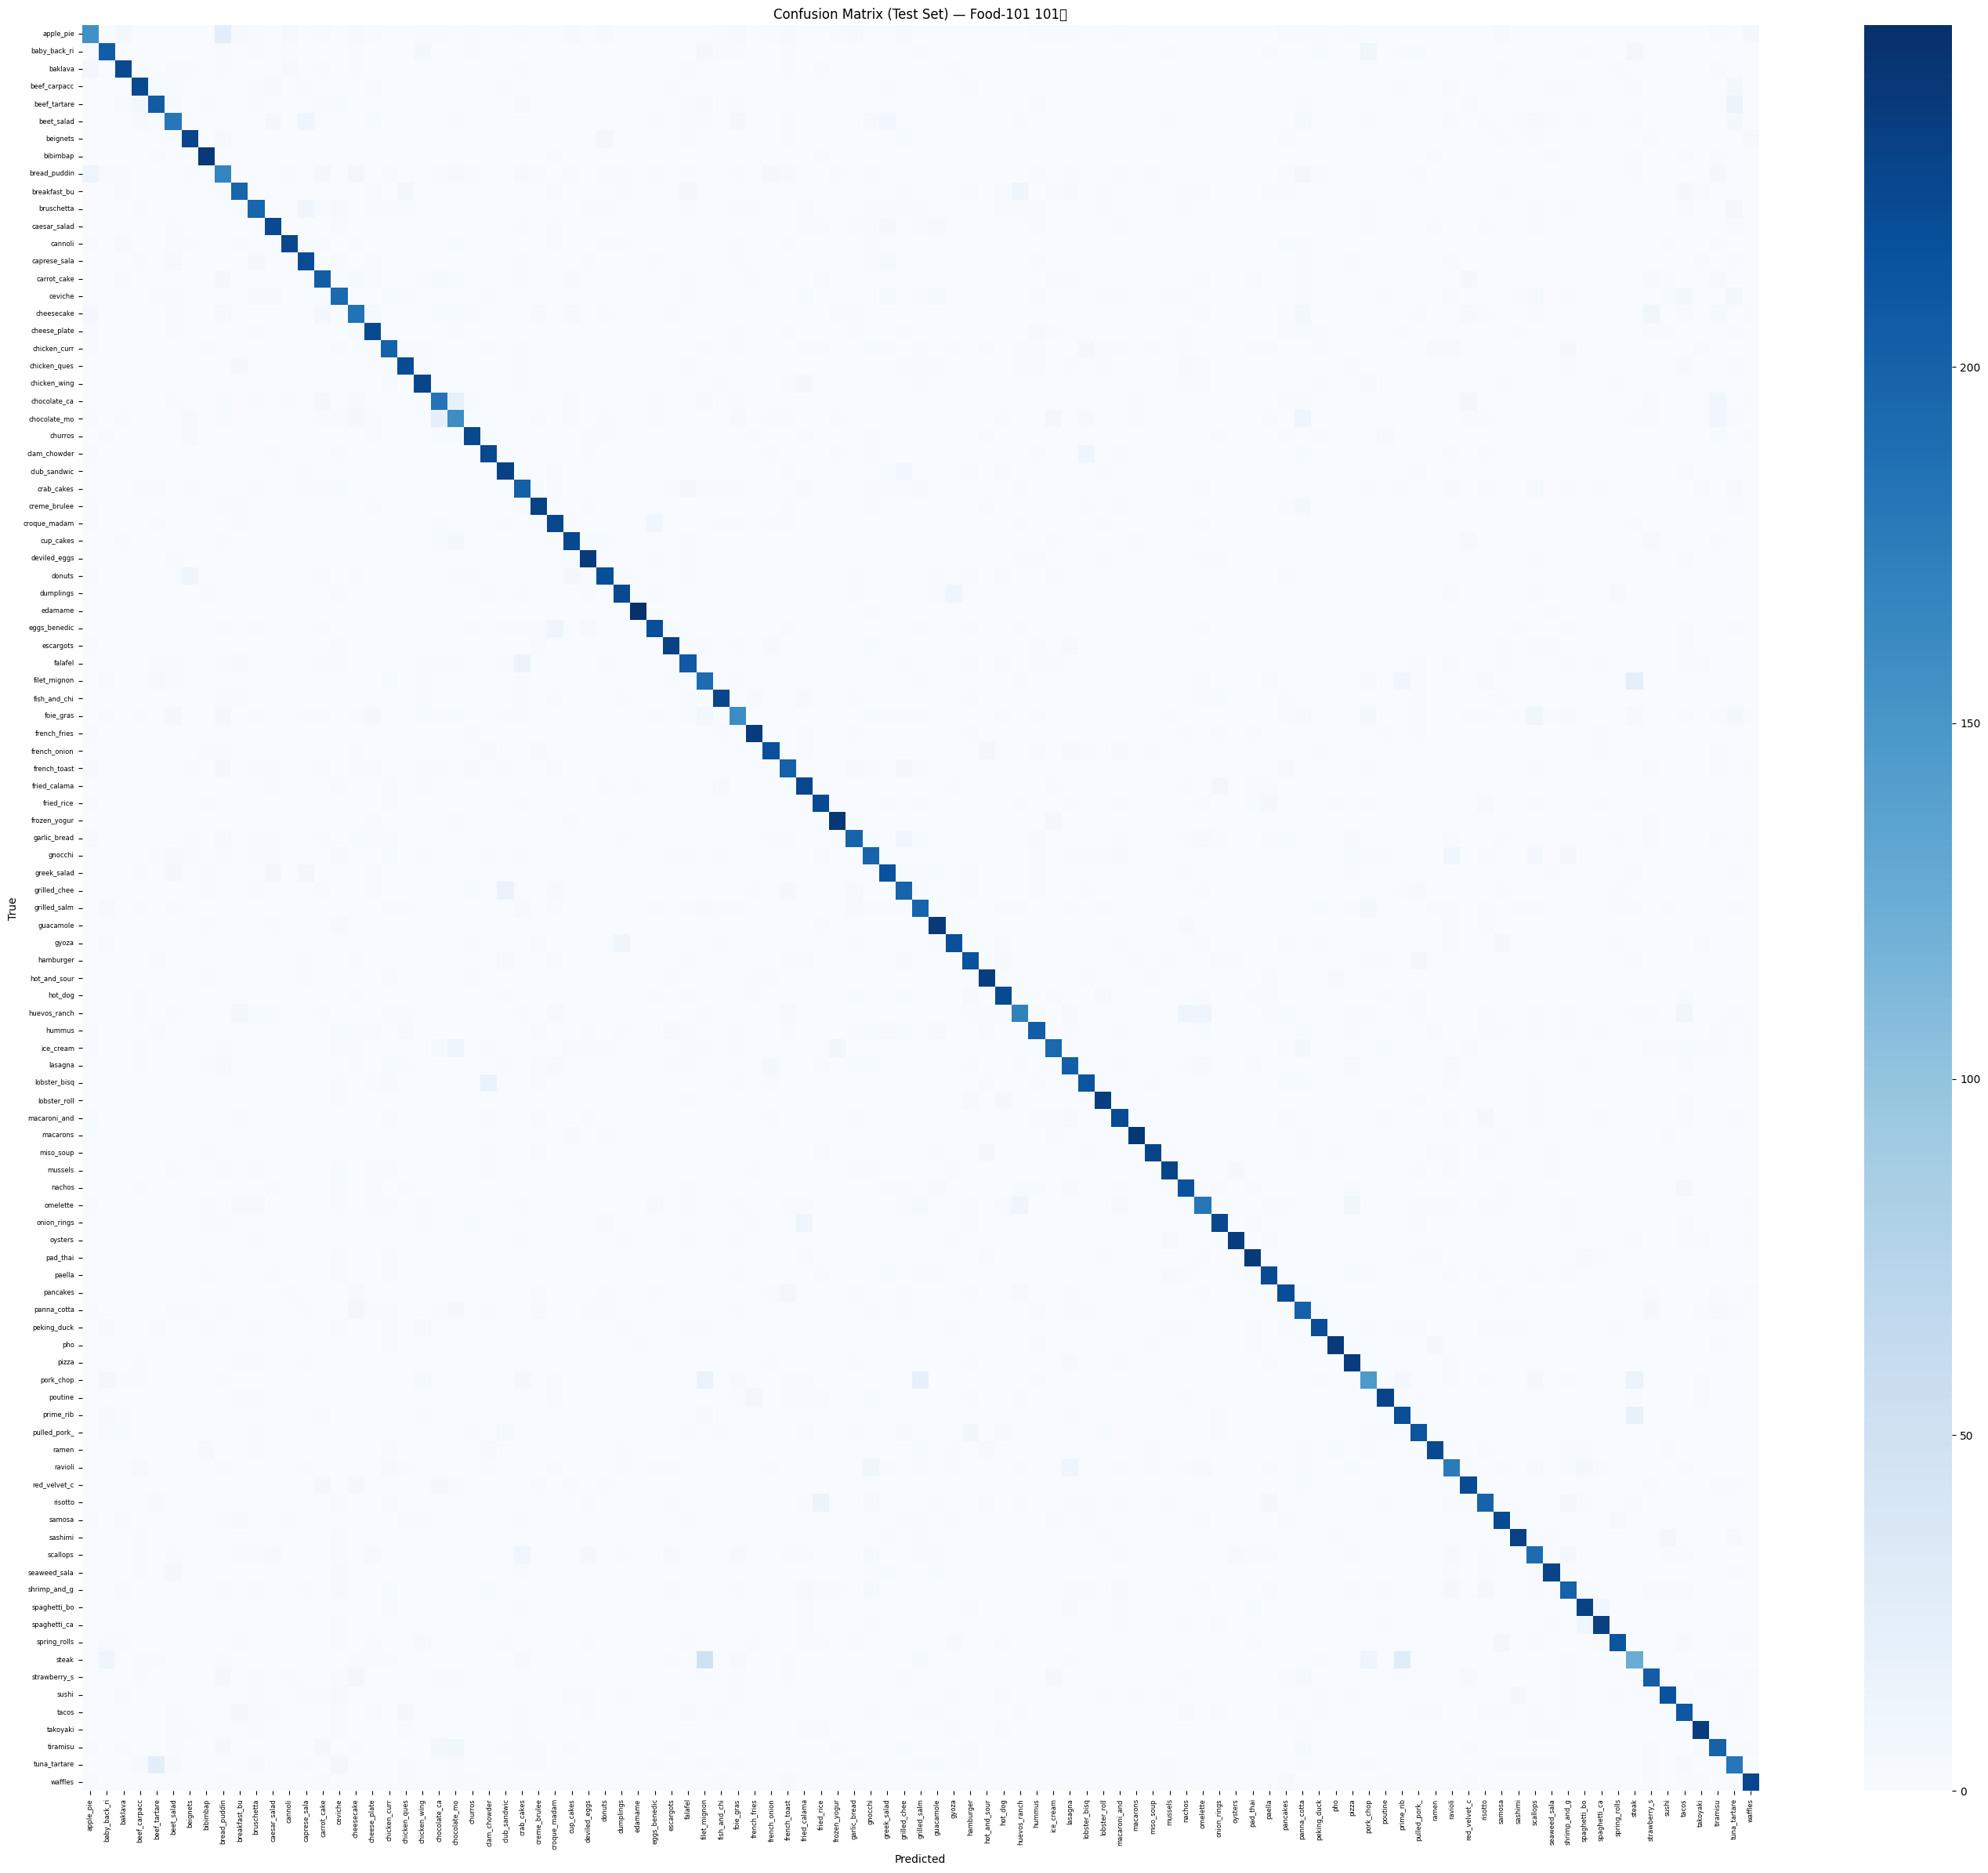

                         precision    recall  f1-score   support

              apple_pie       0.72      0.62      0.67       250
         baby_back_ribs       0.84      0.82      0.83       250
                baklava       0.89      0.90      0.89       250
         beef_carpaccio       0.85      0.90      0.87       250
           beef_tartare       0.82      0.82      0.82       250
             beet_salad       0.77      0.72      0.75       250
               beignets       0.89      0.91      0.90       250
               bibimbap       0.92      0.96      0.94       250
          bread_pudding       0.64      0.67      0.65       250
      breakfast_burrito       0.82      0.79      0.80       250
             bruschetta       0.80      0.78      0.79       250
           caesar_salad       0.87      0.90      0.88       250
                cannoli       0.94      0.90      0.92       250
          caprese_salad       0.82      0.88      0.85       250
            carrot_cake 

In [13]:
# Confusion Matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true      = np.array(y_true)
y_pred      = np.array(y_pred)
cm          = confusion_matrix(y_true, y_pred)
short_names = [c[:12] for c in all_class_names]  # 101종

# 101×101 행렬 — annot 끄고 크기 확대
plt.figure(figsize=(28, 24))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names
)
plt.title('Confusion Matrix (Test Set) — Food-101 101종')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=all_class_names))


## 🔟 TFLite 변환 (Float16)

In [14]:
# ─────────────────────────────────────────────────────────────
#  Float16 양자화
#  - INT8 대비 정확도 손실 최소 (~1%)
#  - EfficientNetV2의 Fused-MBConv와 궁합 좋음
#  - 크기: fp32 ~28MB → fp16 ~14MB
# ─────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

print('TFLite Float16 변환 중...')
tflite_model = converter.convert()

MODEL_PATH = '/content/efficientnetv2b0_food.tflite'
with open(MODEL_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'\n✅ TFLite 저장 완료: {size_mb:.2f} MB')

TFLite Float16 변환 중...
Saved artifact at '/tmp/tmp8o72f09p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  133586324154192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324153040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324155152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324156112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324156688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324154576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324153616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324156496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324155344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133586324157456: TensorSpec(shape=(), dtype=tf.resource, nam

In [15]:
# TFLite 정확도 검증
interp = tf.lite.Interpreter(model_path=MODEL_PATH)
interp.allocate_tensors()

inp = interp.get_input_details()
out = interp.get_output_details()
print(f'입력 shape : {inp[0]["shape"]}  dtype: {inp[0]["dtype"]}')
print(f'출력 shape : {out[0]["shape"]}  dtype: {out[0]["dtype"]}')

correct, total = 0, 0
for images, labels in test_ds.unbatch().batch(1).take(300):
    interp.set_tensor(inp[0]['index'], images.numpy())
    interp.invoke()
    pred     = np.argmax(interp.get_tensor(out[0]['index']))
    correct += int(pred == labels.numpy()[0])
    total   += 1

tflite_acc = correct / total
keras_acc  = max(history2.history['val_accuracy'])
print(f'\nKeras   val_accuracy : {keras_acc:.4f}  ({keras_acc*100:.1f}%)')
print(f'TFLite  accuracy     : {tflite_acc:.4f}  ({tflite_acc*100:.1f}%)')
print(f'정확도 차이           : {abs(keras_acc - tflite_acc)*100:.1f}%p')

입력 shape : [  1 224 224   3]  dtype: <class 'numpy.float32'>
출력 shape : [  1 101]  dtype: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Keras   val_accuracy : 0.8050  (80.5%)
TFLite  accuracy     : 0.8267  (82.7%)
정확도 차이           : 2.2%p


## 1️⃣1️⃣ labels.json 생성

In [16]:
KOREAN_NAMES = {
    'apple_pie': '애플 파이',
    'baby_back_ribs': '베이비 백 립',
    'baklava': '바클라바',
    'beef_carpaccio': '비프 카르파초',
    'beef_tartare': '비프 타르타르',
    'beet_salad': '비트 샐러드',
    'beignets': '베녜',
    'bibimbap': '비빔밥',
    'bread_pudding': '브레드 푸딩',
    'breakfast_burrito': '아침 부리토',
    'bruschetta': '브루스케타',
    'caesar_salad': '시저 샐러드',
    'cannoli': '카놀리',
    'caprese_salad': '카프레제 샐러드',
    'carrot_cake': '당근 케이크',
    'ceviche': '세비체',
    'cheesecake': '치즈케이크',
    'cheese_plate': '치즈 플레이트',
    'chicken_curry': '치킨 카레',
    'chicken_quesadilla': '치킨 퀘사디아',
    'chicken_wings': '치킨 윙',
    'chocolate_cake': '초코 케이크',
    'chocolate_mousse': '초콜릿 무스',
    'churros': '추로스',
    'clam_chowder': '클램 차우더',
    'club_sandwich': '클럽 샌드위치',
    'crab_cakes': '크랩 케이크',
    'creme_brulee': '크렘 브륄레',
    'croque_madame': '크로크 마담',
    'cup_cakes': '컵케이크',
    'deviled_eggs': '데빌드 에그',
    'donuts': '도넛',
    'dumplings': '만두',
    'edamame': '에다마메',
    'eggs_benedict': '에그 베네딕트',
    'escargots': '에스카르고',
    'falafel': '팔라펠',
    'filet_mignon': '필레 미뇽',
    'fish_and_chips': '피시 앤 칩스',
    'foie_gras': '푸아그라',
    'french_fries': '감자튀김',
    'french_onion_soup': '프렌치 어니언 수프',
    'french_toast': '프렌치 토스트',
    'fried_calamari': '프라이드 칼라마리',
    'fried_rice': '볶음밥',
    'frozen_yogurt': '프로즌 요거트',
    'garlic_bread': '마늘빵',
    'gnocchi': '뇨키',
    'greek_salad': '그릭 샐러드',
    'grilled_cheese_sandwich': '그릴드 치즈 샌드위치',
    'grilled_salmon': '연어 구이',
    'guacamole': '과카몰레',
    'gyoza': '교자',
    'hamburger': '햄버거',
    'hot_and_sour_soup': '산라탕',
    'hot_dog': '핫도그',
    'huevos_rancheros': '우에보스 란체로스',
    'hummus': '후무스',
    'ice_cream': '아이스크림',
    'lasagna': '라자냐',
    'lobster_bisque': '랍스터 비스크',
    'lobster_roll_sandwich': '랍스터 롤 샌드위치',
    'macaroni_and_cheese': '맥앤치즈',
    'macarons': '마카롱',
    'miso_soup': '미소국',
    'mussels': '홍합찜',
    'nachos': '나초',
    'omelette': '오믈렛',
    'onion_rings': '어니언 링',
    'oysters': '굴',
    'pad_thai': '팟타이',
    'paella': '파에야',
    'pancakes': '팬케이크',
    'panna_cotta': '판나코타',
    'peking_duck': '베이징 덕',
    'pho': '쌀국수(포)',
    'pizza': '피자',
    'pork_chop': '포크 찹',
    'poutine': '푸틴',
    'prime_rib': '프라임 립',
    'pulled_pork_sandwich': '풀드 포크 샌드위치',
    'ramen': '라면',
    'ravioli': '라비올리',
    'red_velvet_cake': '레드 벨벳 케이크',
    'risotto': '리조또',
    'samosa': '사모사',
    'sashimi': '사시미',
    'scallops': '가리비',
    'seaweed_salad': '해초 샐러드',
    'shrimp_and_grits': '새우 그릿츠',
    'spaghetti_bolognese': '스파게티 볼로네제',
    'spaghetti_carbonara': '스파게티 카르보나라',
    'spring_rolls': '스프링 롤',
    'steak': '스테이크',
    'strawberry_shortcake': '딸기 쇼트케이크',
    'sushi': '스시',
    'tacos': '타코',
    'takoyaki': '타코야키',
    'tiramisu': '티라미수',
    'tuna_tartare': '참치 타르타르',
    'waffles': '와플',
}

# all_class_names 순서(알파벳 정렬, 인덱스=모델 출력 인덱스)로 labels.json 생성
LABELS_DATA = [
    {
        'index':   idx,
        'label':   cls,
        'name_ko': KOREAN_NAMES.get(cls, cls),  # 누락 시 영문 레이블 폴백
    }
    for idx, cls in enumerate(all_class_names)
]

assert len(LABELS_DATA) == 101, f'❌ {len(LABELS_DATA)}개 (101개 필요)'

LABELS_PATH = '/content/labels.json'
with open(LABELS_PATH, 'w', encoding='utf-8') as f:
    json.dump(LABELS_DATA, f, ensure_ascii=False, indent=2)

print(f'✅ labels.json 생성 완료 ({len(LABELS_DATA)}종)')
print(json.dumps(LABELS_DATA, ensure_ascii=False, indent=2))


✅ labels.json 생성 완료 (101종)
[
  {
    "index": 0,
    "label": "apple_pie",
    "name_ko": "애플 파이"
  },
  {
    "index": 1,
    "label": "baby_back_ribs",
    "name_ko": "베이비 백 립"
  },
  {
    "index": 2,
    "label": "baklava",
    "name_ko": "바클라바"
  },
  {
    "index": 3,
    "label": "beef_carpaccio",
    "name_ko": "비프 카르파초"
  },
  {
    "index": 4,
    "label": "beef_tartare",
    "name_ko": "비프 타르타르"
  },
  {
    "index": 5,
    "label": "beet_salad",
    "name_ko": "비트 샐러드"
  },
  {
    "index": 6,
    "label": "beignets",
    "name_ko": "베녜"
  },
  {
    "index": 7,
    "label": "bibimbap",
    "name_ko": "비빔밥"
  },
  {
    "index": 8,
    "label": "bread_pudding",
    "name_ko": "브레드 푸딩"
  },
  {
    "index": 9,
    "label": "breakfast_burrito",
    "name_ko": "아침 부리토"
  },
  {
    "index": 10,
    "label": "bruschetta",
    "name_ko": "브루스케타"
  },
  {
    "index": 11,
    "label": "caesar_salad",
    "name_ko": "시저 샐러드"
  },
  {
    "index": 12,
    "label": "cannoli",
    "n

## 1️⃣2️⃣ Drive 저장 & 다운로드

In [17]:
files_to_save = {
    MODEL_PATH:                      'efficientnetv2b0_food.tflite',
    LABELS_PATH:                     'labels.json',
    '/content/best_model.keras':     'best_model.keras',
    '/content/training_curves.png':  'training_curves.png',
    '/content/confusion_matrix.png': 'confusion_matrix.png',
    '/content/sample_augmented.png': 'sample_augmented.png',
}

print(f'=== Drive 저장: {SAVE_DIR} ===')
for src, name in files_to_save.items():
    if os.path.exists(src):
        dst = os.path.join(SAVE_DIR, name)
        shutil.copy(src, dst)
        print(f'  ✅ {name:<45} ({os.path.getsize(dst)/1024:.1f} KB)')
    else:
        print(f'  ⚠️  {name} — 없음')

print('\n=== Flutter 배포 파일 ===')
print('  efficientnetv2b0_food.tflite  →  assets/models/')
print('  labels.json                   →  assets/models/')

=== Drive 저장: /content/drive/MyDrive/CalorieSnap_final ===
  ✅ efficientnetv2b0_food.tflite                  (11757.7 KB)
  ✅ labels.json                                   (8.4 KB)
  ✅ best_model.keras                              (71559.4 KB)
  ✅ training_curves.png                           (55.8 KB)
  ✅ confusion_matrix.png                          (331.9 KB)
  ✅ sample_augmented.png                          (1439.5 KB)

=== Flutter 배포 파일 ===
  efficientnetv2b0_food.tflite  →  assets/models/
  labels.json                   →  assets/models/


In [18]:
from google.colab import files
files.download(MODEL_PATH)
files.download(LABELS_PATH)
print('✅ 다운로드 완료')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료
